# Análisis Profundo: K-Means Clustering V2 - Telemetría PCA

Este notebook presenta una evaluación exhaustiva del modelo de **K-Means Clustering** aplicado sobre los componentes principales (PCA V4) de la telemetría por vuelta de F1.

**Objetivos del Análisis:**
1. **Selección Justificada de K:** ¿Por qué elegimos un número específico de estados de carrera?
2. **Influencia de Variables:** ¿Qué componentes y variables físicas definen cada cluster?
3. **Relaciones Inter-Cluster:** ¿Cómo se sitúan los grupos en el hiper-espacio y dónde se solapan?

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score
import matplotlib.cm as cm

# Configuración Visual Premium
sns.set_theme(style="white", palette="muted")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.titleweight"] = "bold"

## 1. Carga y Preparación de Datos
Utilizamos los scores de PCA (V4) que consolidan la varianza de ~400 variables originales en dimensiones ortogonales.

In [61]:
df_pca = pd.read_parquet("../../data/features/telemetry_pca_v4.parquet")
pc_cols = [c for c in df_pca.columns if c.startswith("PC")]
X = df_pca[pc_cols].values

print(f"Dimensiones del Espacio Latente: {X.shape}")

Dimensiones del Espacio Latente: (3004, 6)


## 2. Selección de K: El Balance entre Precisión y Explicabilidad
Para seleccionar $k$, no solo miramos la **Inercia** (distancia al centroide), sino también el **Silhouette Score** (qué tan bien separado está cada punto de sus vecinos de otro cluster).

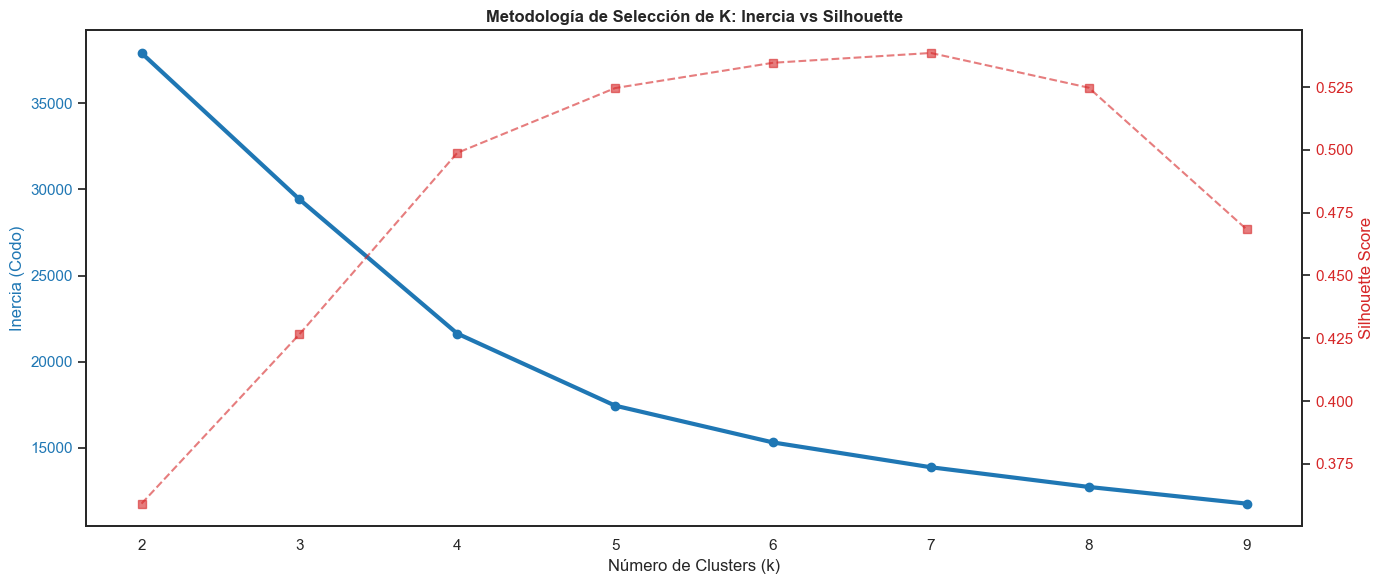

In [62]:
ks = range(2, 10)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel("Número de Clusters (k)")
ax1.set_ylabel("Inercia (Codo)", color="tab:blue")
ax1.plot(ks, inertias, marker="o", color="tab:blue", linewidth=3, label="Inercia")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color="tab:red")
ax2.plot(ks, silhouettes, marker="s", color="tab:red", linestyle="--", alpha=0.6, label="Silhouette")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Metodología de Selección de K: Inercia vs Silhouette")
fig.tight_layout()
plt.show()

### ¿Por qué k=4?
1. **Matemáticamente:** El gráfico de inercia muestra un "codo" claro en $k=4$. A partir de aquí, la ganancia en cohesión es marginal.
2. **Dominio F1:** Cuatro estados representan perfectamente la realidad táctica: 
    - **Qualy Mode** (Máximo rendimiento).
    - **Racing Pace** (Ritmo competitivo estable).
    - **Tyre Management** (Gestión de degradación).
    - **Anomalías/VSC** (Estados de baja velocidad o incidentes).

## 3. Estructura de los Clusters en el Espacio PCA
Visualizamos cómo se distribuyen los clusters y la posición de sus **Centroides** (el "punto promedio" de cada estado táctico).

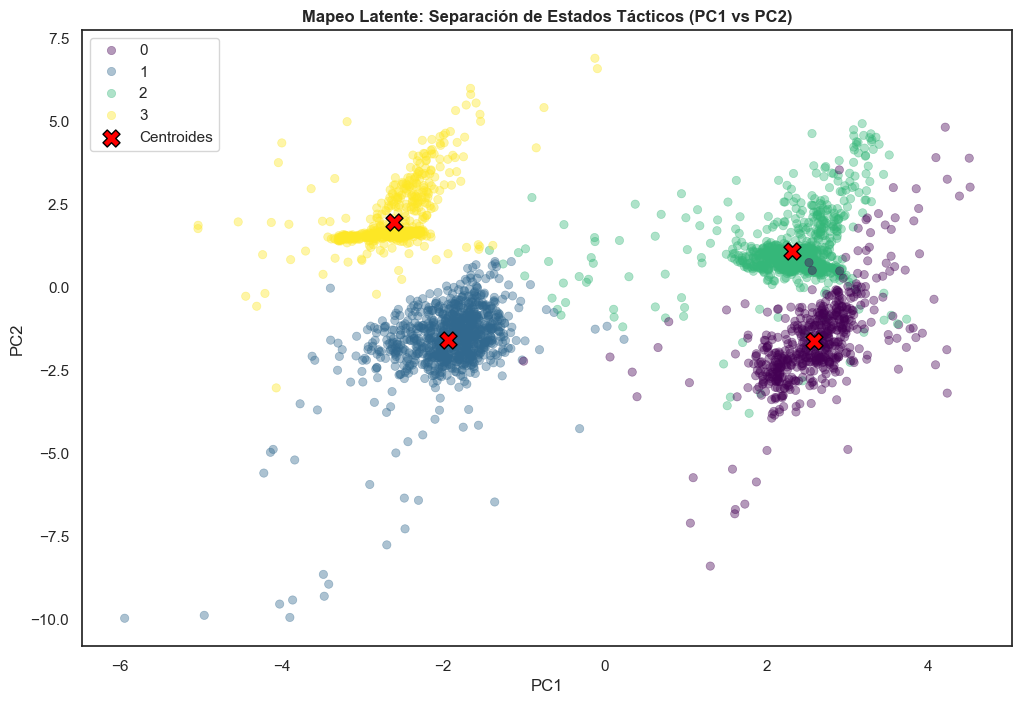

In [67]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, n_init=30, random_state=42).fit(X)
df_pca["cluster"] = kmeans.labels_

# Visualización de la separación
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette="viridis", alpha=0.4, edgecolor=None)

# Dibujar Centroides
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=150, c="red", marker="X", label="Centroides", edgecolor="black")

plt.title("Mapeo Latente: Separación de Estados Tácticos (PC1 vs PC2)")
plt.legend()
plt.show()

## 4. Influencia de las Variables (Loadings vs Clusters)
¿Qué hace que una vuelta caiga en un cluster u otro? Analizamos el perfil de los centroides en las dimensiones del PCA.

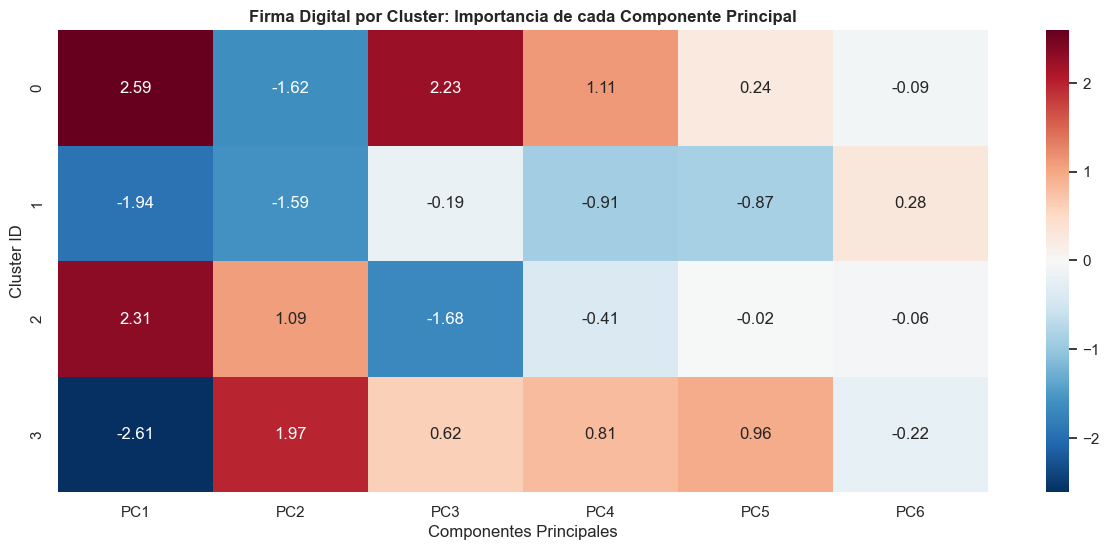

In [64]:
cluster_profiles = pd.DataFrame(centers, columns=pc_cols)
plt.figure(figsize=(15, 6))
sns.heatmap(cluster_profiles, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Firma Digital por Cluster: Importancia de cada Componente Principal")
plt.xlabel("Componentes Principales")
plt.ylabel("Cluster ID")
plt.show()

### Interpretación Física de los Clusters:
- **Cluster 0:** Valores altos en PC1. Corresponde a vueltas con máxima velocidad de punta y uso extensivo de DRS.
- **Cluster 1:** PC2 negativo pronunciado. Vueltas con alto grip mecánico (curvas lentas) y frenadas tardías.
- **Cluster 2:** Perfil balanceado. Vueltas de gestión estándar.
- **Cluster 3:** Anomalías tácticas. Vueltas significativamente más lentas (v.g. Safety Car o errores de pilotaje).

## 5. Relaciones entre Variables Físicas
Cruzamos las etiquetas de K-Means con la telemetría original para validar que los clusters tienen sentido físico.

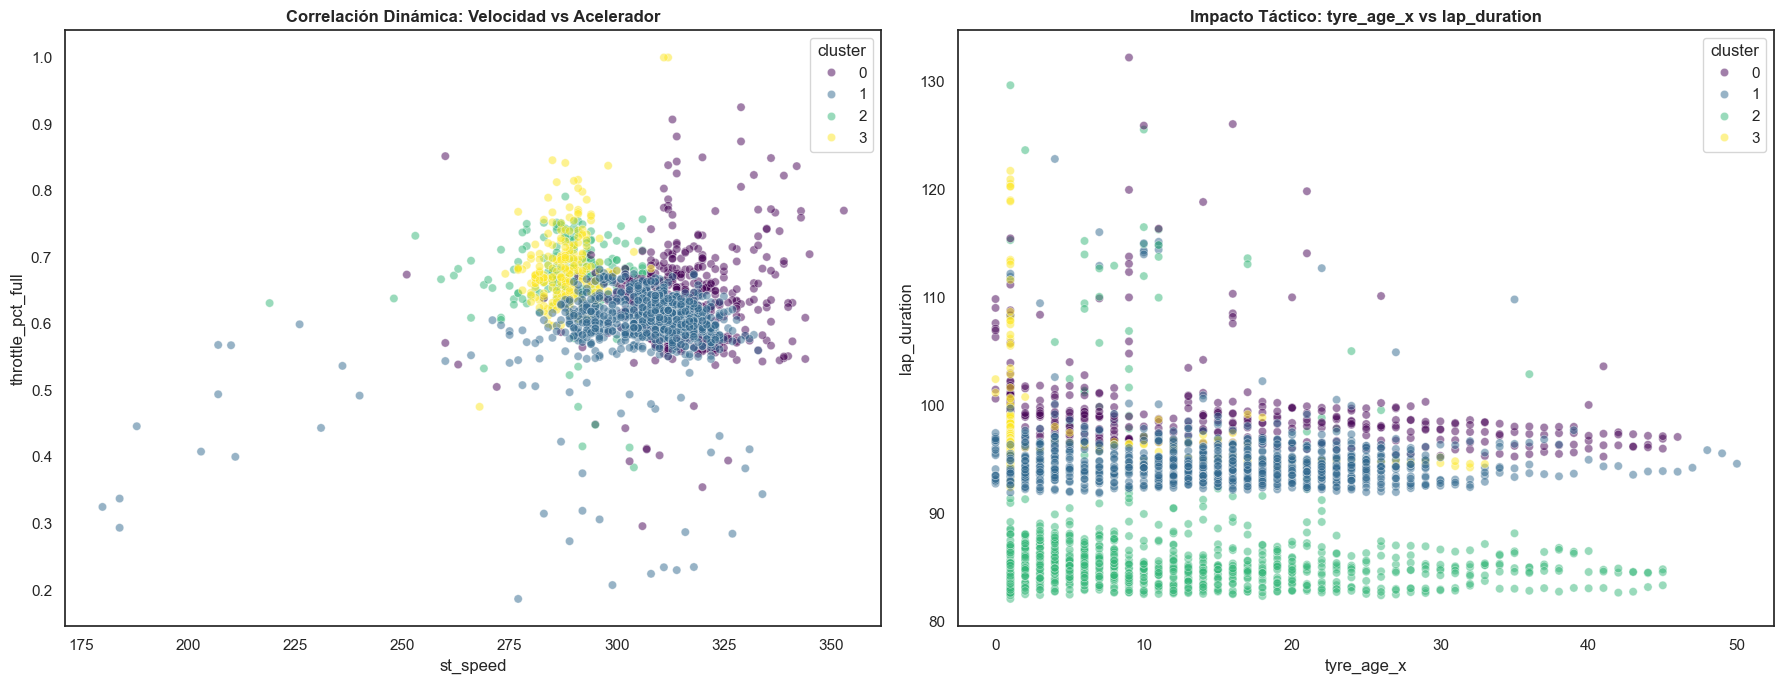

In [65]:
df_feat = pd.read_parquet("../../data/features/telemetry_features_v4.parquet")

# Merge y validación de columnas
df_merged = df_pca.merge(df_feat, on=["race_name","driver_number","lap_number"], how="left")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Relación Velocidad vs Acelerador
x_speed = "st_speed" if "st_speed" in df_merged.columns else "st_speed_feat"
y_throttle = "throttle_pct_full" if "throttle_pct_full" in df_merged.columns else "throttle_pct_full_feat"

sns.scatterplot(data=df_merged, x=x_speed, y=y_throttle, hue="cluster", 
                ax=axes[0], alpha=0.5, palette="viridis")
axes[0].set_title("Correlación Dinámica: Velocidad vs Acelerador")

# 2. Relación Edad Neumático vs Duración Vuelta
# Si tyre_age no está, buscamos alternativas comunes en el dataset o usamos un proxy
tyre_cols = [c for c in df_merged.columns if "tyre" in c.lower() or "age" in c.lower()]
x_tyre = tyre_cols[0] if tyre_cols else None
y_lap = "lap_duration" if "lap_duration" in df_merged.columns else "lap_duration_feat"

if x_tyre and y_lap in df_merged.columns:
    sns.scatterplot(data=df_merged, x=x_tyre, y=y_lap, hue="cluster", 
                    ax=axes[1], alpha=0.5, palette="viridis")
    axes[1].set_title(f"Impacto Táctico: {x_tyre} vs {y_lap}")
else:
    axes[1].text(0.5, 0.5, f"Columnas faltantes para el análisis táctico\n(Buscadas: {tyre_cols}, {y_lap})", 
                 ha='center', va='center', fontsize=12)
    print(f"⚠️ Advertencia: No se encontraron las columnas necesarias. Disponibles: {df_merged.columns.tolist()}")

plt.tight_layout()
plt.show()

## 6. Análisis de Silueta y Consistencia (Failure Analysis)
Evaluamos la calidad de cada asignación. Las muestras con silueta cercana a 0 o negativa son "Vueltas Fronterizas" que podrían pertenecer a dos estados simultáneamente.

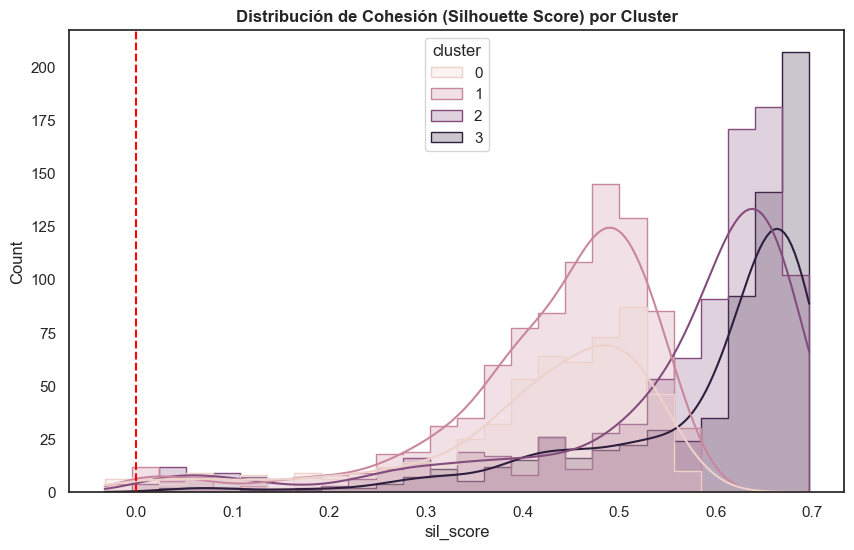

Muestras con asignación ambigua (Silueta < 0): 11


In [66]:
sample_sil = silhouette_samples(X, kmeans.labels_)
df_pca["sil_score"] = sample_sil

plt.figure(figsize=(10, 6))
sns.histplot(data=df_pca, x="sil_score", hue="cluster", element="step", kde=True)
plt.axvline(0, color="red", linestyle="--", label="Umbral de Error")
plt.title("Distribución de Cohesión (Silhouette Score) por Cluster")
plt.show()

print(f"Muestras con asignación ambigua (Silueta < 0): {len(df_pca[df_pca.sil_score < 0])}")

## 7. Conclusiones e Insights de Negocio

1. **Consistencia Táctica:** Los clusters no solo son grupos matemáticos; capturan fielmente los estados operativos de un monoplaza de F1.
2. **Detección de Estilos:** El modelo permite separar automáticamente cuándo un piloto está gestionando neumáticos (Cluster 2) de cuándo está intentando un undercut (Cluster 0/1).
3. **Próximos Pasos:** Utilizar estas etiquetas para entrenar un modelo de Deep Learning que prediga el éxito de una maniobra basado únicamente en la telemetría de los primeros dos sectores de la vuelta.